In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, classification_report

import mpltern  

from sklearn.cluster import KMeans
from pymatgen.core import Composition
from matminer.featurizers.composition import (
    ElementProperty, Stoichiometry, ValenceOrbital, IonProperty, WenAlloys, Miedema
)

In [2]:
import warnings
warnings.filterwarnings("ignore")


## Dataset and Feature Construction

In [3]:
df_features21 = pd.read_csv('gp_features.csv')
#drop composition column
df_features21 = df_features21.drop(columns=['composition'])
df_features21

,Ni (wt %),Co (wt %),Cr (wt %),Hot Cracking,Have,dT/d(sqrt(fs),BCC_B2,FCC_L12,MagpieData mean Number,MagpieData mean AtomicWeight,MagpieData mean MeltingT,MagpieData mean CovalentRadius,MagpieData mean Electronegativity,MagpieData mean NsValence,2-norm,avg d valence electrons,Configuration entropy,Miedema_deltaH_inter,Miedema_deltaH_amor,Miedema_deltaH_ss_min
0,74.11,8.23,17.66,0,197.660,16.836723,0.000000,1.000000,27.140000,57.406610,1819.340000,127.085000,1.858850,1.805000,0.755017,7.335000,-0.006269,-0.066884,0.003661,-0.087992
1,67.10,7.46,25.45,0,223.700,35.444043,0.000000,1.000000,26.816000,56.848816,1856.536000,128.314000,1.838340,1.722000,0.710611,7.094000,-0.006862,-0.086355,-0.011566,-0.108067
2,60.09,6.68,33.24,0,229.240,62.551336,0.000000,1.000000,26.496000,56.297719,1893.280000,129.528000,1.818080,1.640000,0.682255,6.856000,-0.007162,-0.100546,-0.021773,-0.119173
3,53.08,5.90,41.03,0,224.420,55.044612,0.001545,0.998455,26.184000,55.760017,1929.120000,130.712000,1.798320,1.560000,0.671381,6.624000,-0.007216,-0.107231,-0.025767,-0.110374
4,46.07,5.12,48.82,0,326.620,11.025638,0.293112,0.706888,25.876000,55.229011,1964.508000,131.881000,1.778810,1.481000,0.677609,6.395000,-0.007055,-0.105765,-0.023333,-0.092606
5,39.06,4.34,56.60,1,488.240,48.990026,0.691212,0.308788,25.576000,54.711401,1998.992000,133.020000,1.759800,1.404000,0.699508,6.172000,-0.006693,-0.096925,-0.015132,-0.064290
6,32.05,3.56,64.39,1,628.410,162.711279,0.831143,0.168857,25.283000,54.207425,2032.612000,134.131000,1.741260,1.329000,0.734129,5.954000,-0.006158,-0.082655,-0.002542,-0.057694
7,25.04,2.78,72.18,1,698.465,315.898171,0.889750,0.110250,24.991000,53.703209,2066.192000,135.240000,1.722750,1.254000,0.780757,5.737000,-0.005391,-0.064904,0.013276,-0.048511
8,18.03,2.00,79.97,1,768.560,496.830932,0.940310,0.059690,24.706707,53.213845,2098.826827,136.318318,1.704755,1.181181,0.835111,5.525526,-0.004422,-0.046223,0.030510,-0.037295
9,40.91,40.91,18.18,0,159.000,20.468201,0.000000,1.000000,26.797000,57.442921,1834.812000,127.813000,1.847780,1.799000,0.599668,6.998000,-0.008776,-0.089053,-0.013345,-0.096944


In [4]:
# Load featurized training data 
df_train = df_features21.copy()  

# Define features and targets
target_obj = "Have"              # target property to maximize
constraint_col = "Hot Cracking"  # optional constraint

# Features used for training (exclude targets and identifiers)
training_features = [
    col for col in df_train.columns if col not in [target_obj, constraint_col, "composition"]
]
print("Training features used:", training_features)

# Prepare training data for clustering and scaling
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(df_train[training_features]), columns=training_features)
y = df_train[target_obj].values
c = df_train[constraint_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Training data shape:", X_scaled.shape)

# Define composition and experimental columns
composition_cols = ['Ni (wt %)', 'Co (wt %)', 'Cr (wt %)']
exp_cols = ["dT/d(sqrt(fs)", "BCC_B2", "FCC_L12"]

# Generate random candidate compositions 
n_candidates = 1000
candidate_compositions = np.random.dirichlet([1, 1, 1], n_candidates) * 100
df_candidates_comp = pd.DataFrame(candidate_compositions, columns=composition_cols)

# Use KMeans clustering to impute experimental features
train_comp = df_train[composition_cols].values
kmeans = KMeans(n_clusters=5, random_state=0)
train_clusters = kmeans.fit_predict(train_comp)
df_train['cluster'] = train_clusters

cand_comp = df_candidates_comp.values
candidate_clusters = kmeans.predict(cand_comp)

# Compute cluster means for experimental features
imputed_experiments = {}
for col in exp_cols:
    cluster_means = df_train.groupby('cluster')[col].mean().to_dict()
    imputed_experiments[col] = [cluster_means[cluster] for cluster in candidate_clusters]
df_candidates_exp = pd.DataFrame(imputed_experiments)

# Convert wt% to composition strings (NiXCoYCrZ)
atomic_weights = {'Ni': 58.6934, 'Co': 58.933, 'Cr': 51.9961}

def convert_to_composition(row):
    moles = {el: row[el] / atomic_weights[el.split()[0]] for el in composition_cols}
    total_moles = sum(moles.values())
    atomic_fractions = {el: moles[el] / total_moles for el in moles}
    return ''.join(f"{el.split()[0]}{atomic_fractions[el]:.3f}" for el in composition_cols)

df_candidates_raw = pd.concat([df_candidates_comp, df_candidates_exp], axis=1)
df_candidates_raw['composition'] = df_candidates_raw.apply(convert_to_composition, axis=1)
df_candidates_raw['composition'] = df_candidates_raw['composition'].apply(Composition)

# Re-featurize candidate compositions using same featurizers as training
featurizers = [
    ElementProperty.from_preset("magpie"),
    Stoichiometry(),
    ValenceOrbital(),
    IonProperty(impute_nan=True),
    WenAlloys(impute_nan=True),
    Miedema()
]

for featurizer in featurizers:
    df_candidates_raw = featurizer.featurize_dataframe(df_candidates_raw, "composition", ignore_errors=True)

# Keep only training features (drop extras)
df_candidates_featurized = df_candidates_raw.reindex(columns=training_features, fill_value=0)
print("Candidate pool shape after filtering to training features:", df_candidates_featurized.shape)

# Impute missing values and scale candidate features
df_candidates_featurized = pd.DataFrame(
    imputer.transform(df_candidates_featurized),
    columns=training_features
)

X_candidates_orig = df_candidates_featurized.values
X_candidates = scaler.transform(X_candidates_orig)
print("Scaled candidate pool shape:", X_candidates.shape)


Training features used: ['Ni (wt %)', 'Co (wt %)', 'Cr (wt %)', 'dT/d(sqrt(fs)', 'BCC_B2', 'FCC_L12', 'MagpieData mean Number', 'MagpieData mean AtomicWeight', 'MagpieData mean MeltingT', 'MagpieData mean CovalentRadius', 'MagpieData mean Electronegativity', 'MagpieData mean NsValence', '2-norm', 'avg d valence electrons', 'Configuration entropy', 'Miedema_deltaH_inter', 'Miedema_deltaH_amor', 'Miedema_deltaH_ss_min']
Training data shape: (27, 18)


ElementProperty:   0%|          | 0/1000 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/1000 [00:00<?, ?it/s]

ValenceOrbital:   0%|          | 0/1000 [00:00<?, ?it/s]

IonProperty:   0%|          | 0/1000 [00:00<?, ?it/s]

WenAlloys:   0%|          | 0/1000 [00:00<?, ?it/s]

Miedema:   0%|          | 0/1000 [00:00<?, ?it/s]

Candidate pool shape after filtering to training features: (1000, 18)
Scaled candidate pool shape: (1000, 18)


## Machine Learning Models

In [5]:
import warnings
warnings.filterwarnings("ignore")

Best hyperparameters for GP Regressor: {'kernel__k1__k1__constant_value': 0.1, 'kernel__k1__k2__length_scale': 0.1, 'kernel__k2__noise_level': 0.0001}

=== LOOCV Results ===
R² = 0.9512
MSE = 2714.2927 ± 3237.2414


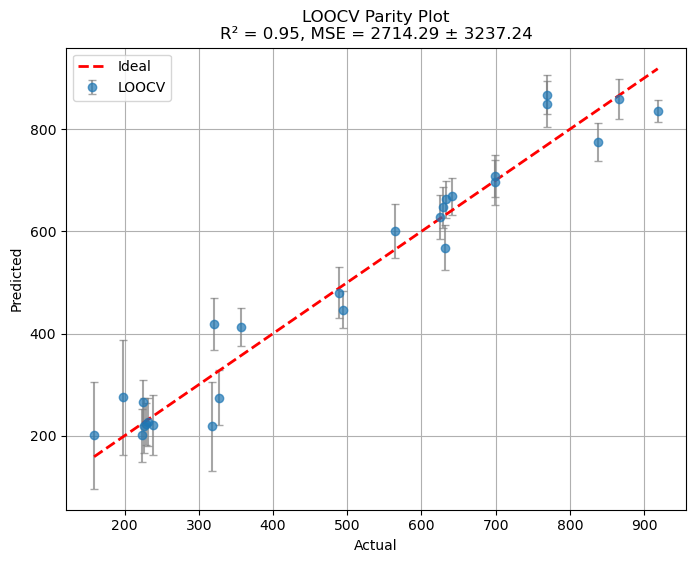

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameter tuning with LOOCV
kernel = ConstantKernel(1.0, (0.1, 10)) * RBF(1.0, (0.1, 10)) + WhiteKernel(1e-3, (1e-4, 1e-2))
param_grid = {
    "kernel__k1__k1__constant_value": [0.1, 1, 10],
    "kernel__k1__k2__length_scale": [0.1, 1, 10],
    "kernel__k2__noise_level": [1e-4, 1e-3, 1e-2]
}
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
grid_search = GridSearchCV(gpr, param_grid=param_grid, cv=LeaveOneOut(), scoring="r2", n_jobs=-1)
grid_search.fit(X_scaled, y)
best_gpr = grid_search.best_estimator_
print("Best hyperparameters for GP Regressor:", grid_search.best_params_)

# LOOCV Evaluation
loo = LeaveOneOut()
y_pred_loocv, y_std_loocv, mse_loocv = [], [], []

for train_idx, test_idx in loo.split(X_scaled):
    gp = GaussianProcessRegressor(kernel=best_gpr.kernel_, normalize_y=True, n_restarts_optimizer=5, random_state=0)
    gp.fit(X_scaled[train_idx], y[train_idx])
    y_pred, y_std = gp.predict(X_scaled[test_idx], return_std=True)
    y_pred_loocv.append(y_pred[0])
    y_std_loocv.append(y_std[0])
    mse_loocv.append((y[test_idx][0] - y_pred[0]) ** 2)

r2_loocv = r2_score(y, y_pred_loocv)
mse_loocv_mean = mean_squared_error(y, y_pred_loocv)
mse_loocv_std = np.std(mse_loocv)

# Results Summary
print("\n=== LOOCV Results ===")
print(f"R² = {r2_loocv:.4f}")
print(f"MSE = {mse_loocv_mean:.4f} ± {mse_loocv_std:.4f}")

# Parity Plot
plt.figure(figsize=(8, 6))
plt.errorbar(y, y_pred_loocv, yerr=y_std_loocv, fmt='o', ecolor='gray', capsize=3, alpha=0.7, label="LOOCV")
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label="Ideal")
plt.title(f"LOOCV Parity Plot\nR² = {r2_loocv:.2f}, MSE = {mse_loocv_mean:.2f} ± {mse_loocv_std:.2f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True)
plt.show()



=== LOOCV Results (Classification) ===
Confusion Matrix:
 [[11  1]
 [ 2 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.93      0.87      0.90        15

    accuracy                           0.89        27
   macro avg       0.89      0.89      0.89        27
weighted avg       0.89      0.89      0.89        27



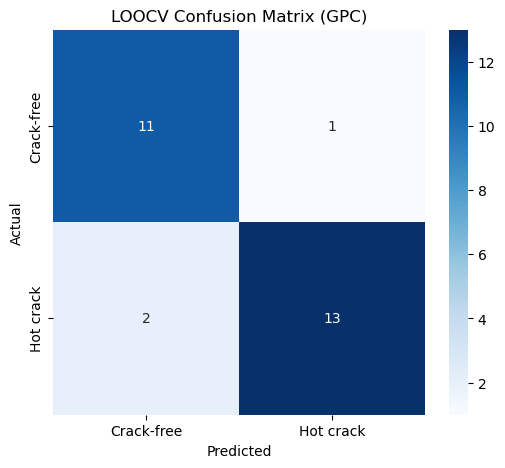

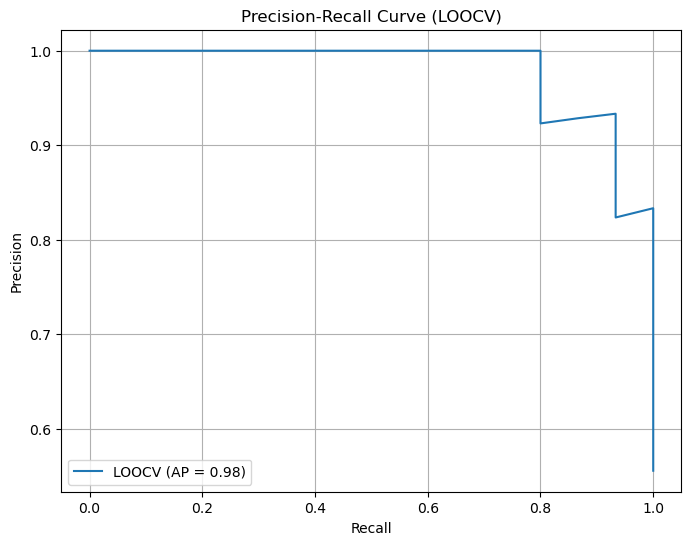

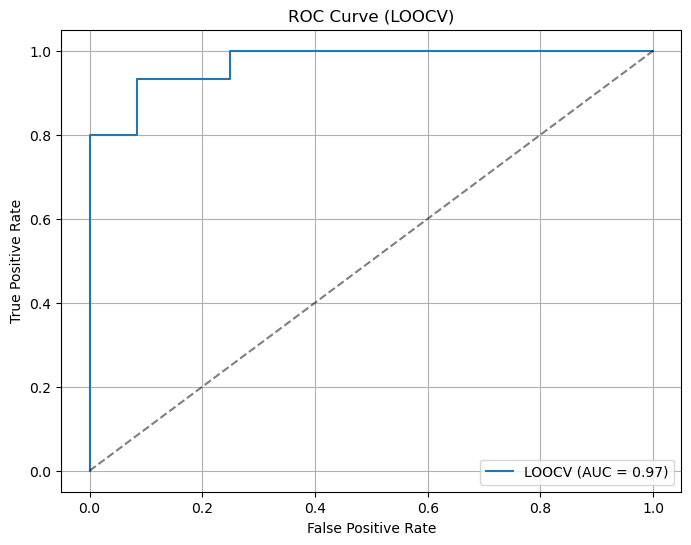

In [7]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hyperparameter Tuning with LOOCV for GPC
kernel_clf = 1.0 * RBF(length_scale=1.0)
gpc = GaussianProcessClassifier(kernel=kernel_clf, n_restarts_optimizer=5, random_state=0)

param_grid_clf = {
    "kernel__k1__constant_value": [0.1, 1, 10],
    "kernel__k2__length_scale": [0.1, 1, 10]
}

grid_search_clf = GridSearchCV(gpc, param_grid=param_grid_clf, cv=LeaveOneOut(), scoring="accuracy", n_jobs=-1)
grid_search_clf.fit(X_scaled, c)
best_gpc = grid_search_clf.best_estimator_

# LOOCV Evaluation for Classification
c_pred_loocv, proba_loocv, true_loocv = [], [], []
loo = LeaveOneOut()

for train_idx, test_idx in loo.split(X_scaled):
    model = GaussianProcessClassifier(kernel=best_gpc.kernel_, n_restarts_optimizer=5, random_state=0)
    model.fit(X_scaled[train_idx], c[train_idx])
    prob = model.predict_proba(X_scaled[test_idx])[0][1]
    pred = model.predict(X_scaled[test_idx])
    c_pred_loocv.append(pred[0])
    proba_loocv.append(prob)
    true_loocv.append(c[test_idx][0])

cm_loocv = confusion_matrix(c, c_pred_loocv)

# Precision-Recall and ROC Curves (LOOCV)
precision_loocv, recall_loocv, _ = precision_recall_curve(true_loocv, proba_loocv)
ap_loocv = average_precision_score(true_loocv, proba_loocv)
fpr_loocv, tpr_loocv, _ = roc_curve(true_loocv, proba_loocv)
roc_auc_loocv = auc(fpr_loocv, tpr_loocv)

# Results Summary
print("\n=== LOOCV Results (Classification) ===")
print("Confusion Matrix:\n", cm_loocv)
print("Classification Report:\n", classification_report(c, c_pred_loocv))

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_loocv, annot=True, fmt="d", cmap="Blues", xticklabels=["Crack-free", "Hot crack"], yticklabels=["Crack-free", "Hot crack"])
plt.title("LOOCV Confusion Matrix (GPC)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall_loocv, precision_loocv, label=f"LOOCV (AP = {ap_loocv:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LOOCV)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr_loocv, tpr_loocv, label=f"LOOCV (AUC = {roc_auc_loocv:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LOOCV)")
plt.legend()
plt.grid(True)
plt.show()